In [1]:
import pandas as pd
import sys
import importlib

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
sys.path.append("../src")
import modeling as mod
import visualization as visual
import grid_search as gs
import modeling_utils as utils

importlib.reload(mod)
importlib.reload(visual)
importlib.reload(gs)
importlib.reload(utils)

<module 'modeling_utils' from '/Users/isacassanello/Desktop/tercero/aprendizaje automatico y profundo/TP_Final_ML/notebooks/../src/modeling_utils.py'>

In [4]:
X_train = pd.read_csv("../data/X_train.csv")
X_val = pd.read_csv("../data/X_val.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_val = pd.read_csv("../data/y_val.csv").squeeze()

<h1 style="
    background-color: #d0ebff; 
    color: #1a1a1a; 
    display: inline-block; 
    padding: 10px 18px; 
    border-radius: 10px;
    font-size: 32px;
">
Predictive Modeling
</h1>

En esta sección se entrenan y evalúan distintos modelos de regresión para estimar el precio de SUVs en dólares. Primero se utiliza una regresión lineal como modelo base, y luego se comparará su desempeño contra modelos más complejos.

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Baseline Model: Linear Regression
</h3>

La regresión lineal se utiliza como modelo base porque permite obtener una primera referencia del error predictivo. Este modelo asume una relación lineal entre las variables de entrada y el precio, por lo que sirve como punto de comparación para evaluar si modelos más complejos logran mejorar la predicción.

La métrica principal utilizada será el MSE, que mide el promedio de los errores cuadráticos entre el precio real y el precio predicho.

In [5]:
linear_model, linear_metrics = mod.train_linear_regression(X_train, y_train, X_val, y_val)

,train_mse,val_mse,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2
0,9.791451e+07,1.255094e+08,9895.175874,11203.096003,4958.323089,5321.39539,0.761759,0.701458


In [6]:
X_train.isna().sum()[X_train.isna().sum() > 0].sort_values(ascending=False)

Con cámara de retroceso    10447
Cilindrada                    16
dtype: int64

In [7]:
X_val.isna().sum()[X_val.isna().sum() > 0].sort_values(ascending=False)

Con cámara de retroceso    2623
Cilindrada                    6
dtype: int64

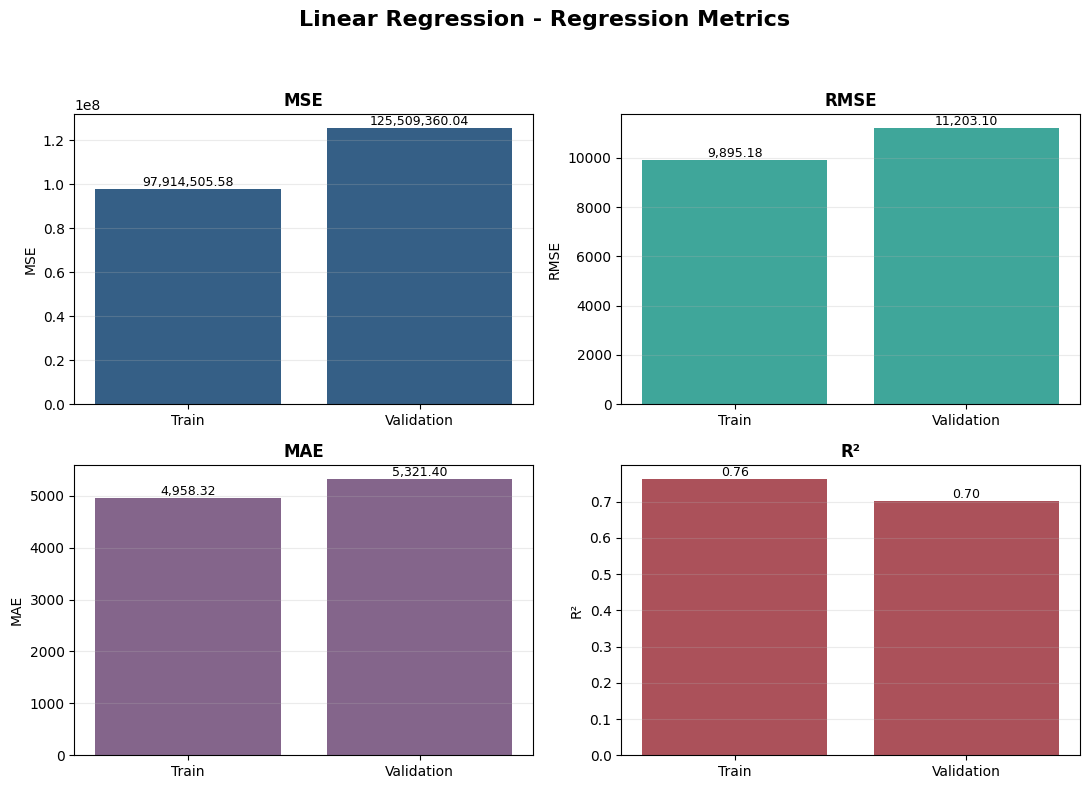

In [8]:
visual.plot_regression_metrics(
    linear_metrics,
    model_name="Linear Regression"
)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Ridge Regression
</h3>

La regresión Ridge es una extensión de la regresión lineal que incorpora regularización L2. Este término de penalización evita que los coeficientes del modelo tomen valores excesivamente grandes, reduciendo así el riesgo de sobreajuste.

En este trabajo resulta especialmente útil debido a la aplicación de One-Hot Encoding sobre variables categóricas como la marca, el modelo, el color y el tipo de combustible, lo que incrementa considerablemente el número de variables predictoras y puede generar correlaciones entre ellas.

Al igual que en la regresión lineal, el desempeño del modelo se evaluará utilizando como métrica principal el Error Cuadrático Medio (MSE), complementando el análisis con RMSE, MAE y R².

In [9]:
ALPHAS = (0.001, 0.01, 0.1, 1, 10, 100, 500, 1000)

best_ridge_alpha, ridge_cv_results = gs.find_best_alpha_ridge(
    X_train, y_train, alphas=ALPHAS, cv=5,
)

print(f"Best Ridge alpha: {best_ridge_alpha}")
ridge_cv_results  # tabla con mean_cv_mse y std_cv_mse por alpha

Best Ridge alpha: 0.0001


,alpha,mean_cv_mse,std_cv_mse
0,0.0001,1.109985e+08,3.090822e+07
1,0.0005,1.109985e+08,3.090821e+07
2,0.0010,1.109985e+08,3.090821e+07
3,0.0050,1.109985e+08,3.090821e+07
4,0.0100,1.109986e+08,3.090820e+07
5,0.0500,1.109988e+08,3.090816e+07
6,0.1000,1.109992e+08,3.090811e+07
7,1.0000,1.110053e+08,3.090721e+07
8,10.0000,1.110705e+08,3.090281e+07
9,100.0000,1.119637e+08,3.108677e+07


In [10]:
ridge_model, ridge_metrics = mod.train_ridge_regression(
    X_train, y_train, X_val, y_val, alpha=best_ridge_alpha,
)

,train_mse,val_mse,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2
0,9.791451e+07,1.255093e+08,9895.175874,11203.095164,4958.323022,5321.395158,0.761759,0.701458


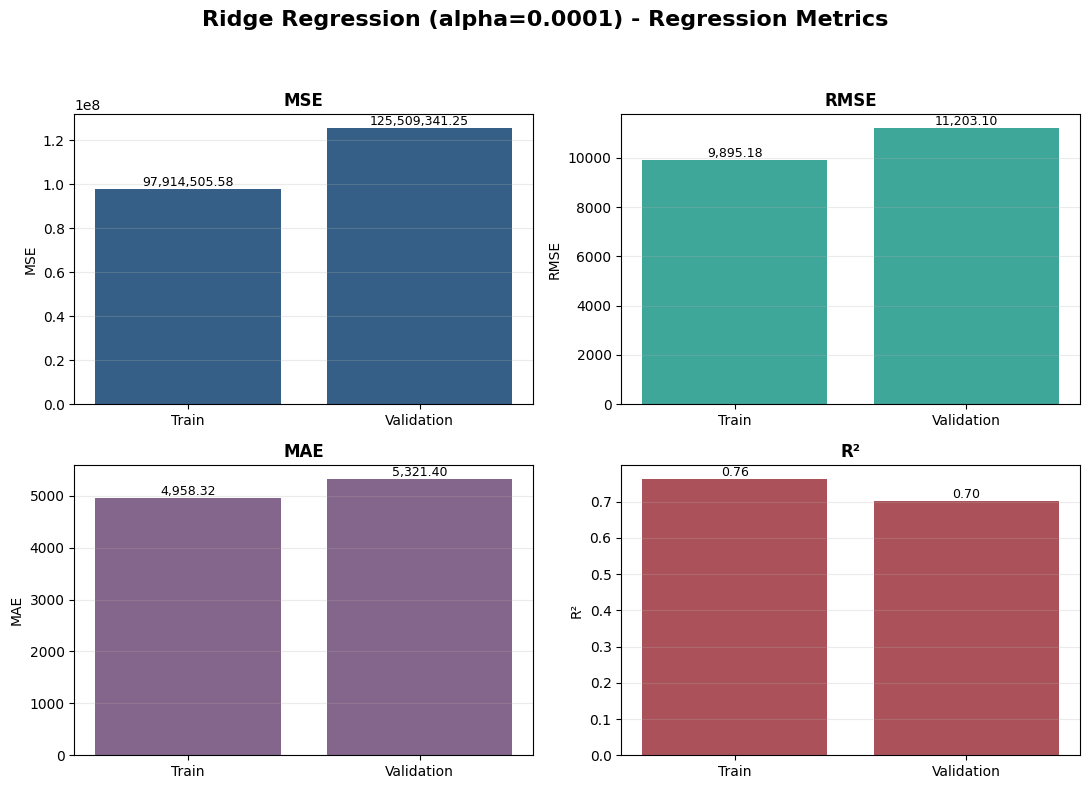

In [11]:
visual.plot_regression_metrics(
    ridge_metrics,
    model_name=f"Ridge Regression (alpha={best_ridge_alpha})"
)

### Ridge Regression: análisis del resultado

Ridge Regression se incorporó como una extensión de la regresión lineal con regularización L2. El objetivo de este modelo es penalizar coeficientes demasiado grandes para reducir el riesgo de overfitting, especialmente cuando existen muchas variables predictoras o alta multicolinealidad entre ellas.

Sin embargo, en este caso Ridge no produjo una mejora significativa respecto de la regresión lineal. Esto puede explicarse porque, aunque el dataset tiene muchas variables luego del One-Hot Encoding, la cantidad de observaciones es suficientemente grande en relación con la cantidad de features. Por lo tanto, el modelo lineal ya se encuentra relativamente bien determinado y no parece estar sufriendo un sobreajuste severo.

Al evaluar distintos valores de `alpha`, las métricas obtenidas fueron muy similares entre sí. Esto indica que aumentar la intensidad de la regularización no mejora de forma relevante la capacidad predictiva del modelo. En otras palabras, penalizar más los coeficientes no reduce sustancialmente el error de validación.

Por este motivo, se seleccionó el valor de `alpha` que obtuvo el menor MSE, aunque la diferencia con otros valores fue pequeña. Este resultado sugiere que, para este problema, Ridge Regression funciona principalmente como una confirmación de que la regresión lineal simple ya constituye una baseline estable.

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
LASSO Regression
</h3>

In [ ]:
# ALPHAS = (0.001, 0.01, 0.1, 1, 10, 100, 500, 1000)

# best_lasso_alpha, lasso_cv_results = gs.find_best_alpha_lasso(
#     X_train, y_train, alphas=ALPHAS, cv=5,
# )

# print(f"Best Lasso alpha: {best_lasso_alpha}")
# lasso_cv_results

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.609e+10, tolerance: 4.926e+08
  model = cd_fast.enet_coordinate_descent(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.492e+10, tolerance: 4.960e+08
  model = cd_fast.enet_coordinate_descent(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.656e+10, to

In [ ]:
# lasso_model, lasso_metrics = mod.train_lasso_regression(
#     X_train, y_train, X_val, y_val, alpha=best_lasso_alpha,
# )
# lasso_metrics

,train_mse,val_mse,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2
0,9.791534e+07,1.247930e+08,9895.218021,11171.07967,4955.675487,5311.039695,0.761757,0.703162


<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Random Forest Regressor
</h3>

In [ ]:
random_forest_model, random_forest_metrics = mod.train_random_forest(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
)

display(random_forest_metrics)